#  Student Dropout Prediction — Random Forest

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Binary Classification — Prediksi Dropout (1) atau Tidak Dropout (0)  
**Model:** Random Forest Classifier

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

| Fungsi | Kegunaan |
|--------|----------|
| `df.info()` | Tipe data, jumlah non-null |
| `df.dtypes` | Tipe data per kolom |
| `df.describe()` | Statistik numerik |
| `df.isnull().sum()` | Jumlah missing values |
| `df.nunique()` | Jumlah nilai unik |
| `df.value_counts()` | Frekuensi nilai kategorik |

In [2]:
df = pd.read_csv('../student_dropout_dataset_v3.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

Missing Values:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

Distribusi Target:
Dropout
0    7646
1    2354
Name: count, dtype: int64


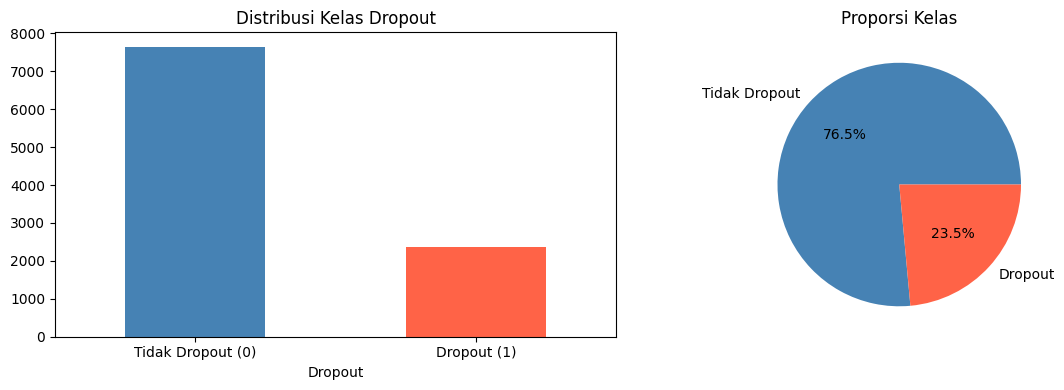

In [4]:
print('Missing Values:')
print(df.isnull().sum())
print('\nDistribusi Target:')
print(df['Dropout'].value_counts())

# Visualisasi distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Dropout'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribusi Kelas Dropout')
axes[0].set_xticklabels(['Tidak Dropout (0)', 'Dropout (1)'], rotation=0)
axes[1].pie(df['Dropout'].value_counts(), labels=['Tidak Dropout', 'Dropout'], autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporsi Kelas')
plt.tight_layout()
plt.show()

---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Target | Jenis Task |
|--------|--------|------------|
| Prediksi Dropout | `Dropout` (0/1) | **Classification** ← (notebook ini) |
| Prediksi CGPA | `CGPA` | Regression |
| Prediksi Semester GPA | `Semester_GPA` | Regression |
| Analisis faktor utama dropout | - | Feature Importance / EDA |
| Early Warning System | Probabilitas dropout | Classification |
| Segmentasi profil mahasiswa | - | Clustering |

---
## 3.  Model Yang Bisa Digunakan

### Mengapa Random Forest?
- **Ensemble** dari banyak Decision Tree → rata-rata prediksi
- **Robust** terhadap outlier dan data tidak linear
- Tidak perlu feature scaling
- Memberikan **feature importance** secara langsung
- Tahan terhadap overfitting dibanding single Decision Tree

| Model | Random Forest | Logistic Reg | XGBoost |
|-------|:---:|:---:|:---:|
| Non-linear boundary |  |  |  |
| Feature importance |  | Koefisien |  |
| Perlu scaling |  |  |  |
| Cepat training | Medium |  |  |
| Interpretable | Medium |  | Medium |

In [5]:
# ============================================================
# PREPROCESSING
# ============================================================
target_col = 'Dropout'
drop_cols = ['Student_ID']

df_proc = df.drop(columns=drop_cols).copy()

# Encode kolom kategorik
le = LabelEncoder()
cat_cols = df_proc.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Catatan: Random Forest TIDAK butuh scaling!
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (8000, 17), Test: (2000, 17)


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `n_estimators` | 100 | Jumlah pohon (tree). Lebih banyak = lebih stabil, tapi lebih lambat. Biasanya 100–500 |
| `max_depth` | None | Kedalaman maksimum tiap pohon. `None` = sampai semua leaf pure (mudah overfit). Set ke 5–20 |
| `min_samples_split` | 2 | Minimum sampel untuk split node. Naikkan untuk regularisasi |
| `min_samples_leaf` | 1 | Minimum sampel di leaf node. Naikkan untuk regularisasi |
| `max_features` | `'sqrt'` | Jumlah fitur yang dipertimbangkan tiap split. `'sqrt'`, `'log2'`, atau float |
| `class_weight` | None | `'balanced'` untuk imbalanced data |
| `bootstrap` | True | Apakah gunakan bootstrap sampling |
| `random_state` | None | Seed untuk reproduktibilitas |
| `n_jobs` | None | `-1` = gunakan semua CPU untuk percepatan |

In [6]:
# ============================================================
# BUILD MODEL RANDOM FOREST
# ============================================================
model = RandomForestClassifier(
    n_estimators=200,        # 200 pohon (coba: 100, 200, 500)
    max_depth=10,            # Kedalaman max (coba: None, 5, 10, 20)
    min_samples_split=5,     # Min sampel untuk split
    min_samples_leaf=2,      # Min sampel di leaf
    max_features='sqrt',     # Fitur per split ('sqrt', 'log2', 0.5)
    class_weight='balanced', # Handle imbalanced
    bootstrap=True,
    random_state=42,
    n_jobs=-1                # Gunakan semua CPU
)

model.fit(X_train, y_train)
print('Model Random Forest berhasil ditraining ')

Model Random Forest berhasil ditraining 


In [7]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

---
## 5.  Evaluasi Yang Dipakai

| Metrik | Formula | Kapan Penting |
|--------|---------|---------------|
| Accuracy | (TP+TN)/Total | Data seimbang |
| Precision | TP/(TP+FP) | Minimasi false alarm |
| Recall | TP/(TP+FN) | Minimasi miss kasus penting |
| F1-Score | Harmonic(P,R) | Data imbalanced |
| ROC-AUC | Area under ROC | Performa pemisahan kelas |
| Confusion Matrix | Tabel TP/TN/FP/FN | Analisis detail error |

In [8]:
print('=' * 50)
print(' EVALUASI MODEL RANDOM FOREST')
print('=' * 50)
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Dropout', 'Dropout']))

 EVALUASI MODEL RANDOM FOREST
Accuracy  : 0.7780
Precision : 0.5235
Recall    : 0.6391
F1-Score  : 0.5755
ROC-AUC   : 0.8096

               precision    recall  f1-score   support

Tidak Dropout       0.88      0.82      0.85      1529
      Dropout       0.52      0.64      0.58       471

     accuracy                           0.78      2000
    macro avg       0.70      0.73      0.71      2000
 weighted avg       0.80      0.78      0.79      2000



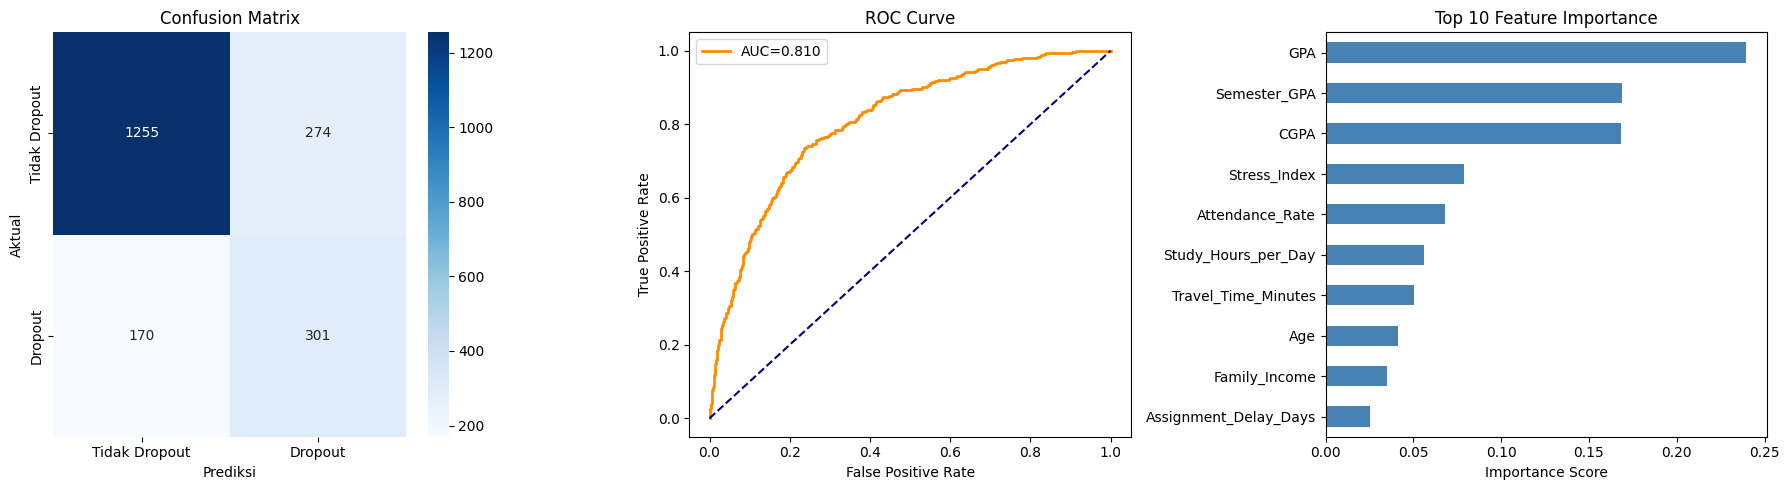

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Dropout', 'Dropout'],
            yticklabels=['Tidak Dropout', 'Dropout'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'navy',linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 Feature Importance')
axes[2].set_xlabel('Importance Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Cross-Val AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Val AUC (5-fold): 0.8085 ± 0.0138


---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### ROC-AUC:
| Nilai | Status |
|-------|--------|
| < 0.6 | Buruk |
| 0.6–0.7 | Cukup |
| 0.7–0.8 | Baik |
| 0.8–0.9 | Sangat Baik |
| > 0.9 | Luar Biasa |

### Deteksi Overfitting:
```
Jika Train Accuracy >> Test Accuracy (selisih > 10%) → OVERFITTING
Jika keduanya rendah → UNDERFITTING  
Jika Train ≈ Test & keduanya tinggi → IDEAL
```

### Cross-Validation:
- Std kecil (< 0.02) → Model stabil
- Std besar (> 0.05) → Variance tinggi, kemungkinan overfitting

In [11]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy  : {test_acc:.4f}')
print(f'Selisih        : {abs(train_acc-test_acc):.4f}')

if abs(train_acc - test_acc) > 0.1:
    print('  Kemungkinan OVERFITTING — kurangi depth, tambah min_samples, kurangi n_estimators')
elif test_acc < 0.7:
    print('  Kemungkinan UNDERFITTING — tambah n_estimators, tambah depth')
else:
    print('  Model terlihat baik!')

Train Accuracy : 0.8700
Test Accuracy  : 0.7780
Selisih        : 0.0920
  Model terlihat baik!


---
## 7.  Cara Mengoptimasi Model

### Jika OVERFITTING:
- Kurangi `max_depth` (misal 5–10)
- Naikkan `min_samples_split` (misal 10–20)
- Naikkan `min_samples_leaf` (misal 5–10)
- Kurangi `n_estimators` (kurang berarti untuk RF)
- Kurangi `max_features` (misal `'log2'`)

### Jika UNDERFITTING:
- Naikkan `max_depth` atau buat `None`
- Naikkan `n_estimators` (200, 500)
- Turunkan `min_samples_split`

### Imbalanced Data:
- `class_weight='balanced'`
- SMOTE oversampling

### Hyperparameter Tuning dengan RandomizedSearchCV:

In [12]:
# RandomizedSearchCV (lebih cepat dari GridSearchCV untuk banyak parameter)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=20,           # Coba 20 kombinasi acak
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rand_search.fit(X_train, y_train)
print(' Best params:', rand_search.best_params_)
print(f' Best AUC: {rand_search.best_score_:.4f}')

 Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'class_weight': None}
 Best AUC: 0.8108


In [13]:
best_model = rand_search.best_estimator_
y_best = best_model.predict(X_test)
y_best_p = best_model.predict_proba(X_test)[:, 1]

print('SETELAH TUNING:')
print(f'  Accuracy : {accuracy_score(y_test, y_best):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_best):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_best_p):.4f}')

SETELAH TUNING:
  Accuracy : 0.7940
  F1-Score : 0.4294
  ROC-AUC  : 0.8091


---
## 8.  Cara Menyimpan Model

Random Forest **tidak memerlukan scaler**, tapi tetap simpan:
1. Model (`.pkl`)
2. Daftar kolom fitur (untuk memastikan urutan kolom saat prediksi benar)
3. Encoder jika ada kolom kategorik

In [14]:
os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_model, 'saved_models/random_forest_dropout.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_columns_rf.pkl')

print(' Model disimpan: saved_models/random_forest_dropout.pkl')
print(' Feature columns disimpan')

# Verifikasi file tersimpan
import os
size = os.path.getsize('saved_models/random_forest_dropout.pkl')
print(f'Ukuran file: {size / 1024:.1f} KB')

 Model disimpan: saved_models/random_forest_dropout.pkl
 Feature columns disimpan
Ukuran file: 1522.1 KB


---
## 9.  Cara Menggunakan Model Hasil Training

In [15]:
# Load model
loaded_model = joblib.load('saved_models/random_forest_dropout.pkl')
loaded_cols = joblib.load('saved_models/feature_columns_rf.pkl')
print('Model dimuat ')

# Contoh data baru (sudah di-encode seperti saat training)
# Urutan kolom HARUS sama persis!
new_data = pd.DataFrame([{
    'Age': 21,
    'Gender': 1,              # Setelah LabelEncode (Male=1, Female=0)
    'Family_Income': 20000,
    'Internet_Access': 1,     # Yes=1, No=0
    'Study_Hours_per_Day': 2.0,
    'Attendance_Rate': 60.0,
    'Assignment_Delay_Days': 5,
    'Travel_Time_Minutes': 45,
    'Part_Time_Job': 1,
    'Scholarship': 0,
    'Stress_Index': 8,
    'GPA': 1.9,
    'Semester_GPA': 1.7,
    'CGPA': 1.8,
    'Semester': 4,
    'Department': 2,
    'Parental_Education': 0
}])

new_data = new_data[loaded_cols]  # Pastikan urutan kolom benar

# Prediksi (Random Forest tidak butuh scaling)
pred = loaded_model.predict(new_data)
prob = loaded_model.predict_proba(new_data)

print('\nHASIL PREDIKSI:')
print(f'  Prediksi : {" DROPOUT" if pred[0] == 1 else " TIDAK DROPOUT"}')
print(f'  Prob Tidak Dropout : {prob[0][0]:.2%}')
print(f'  Prob Dropout       : {prob[0][1]:.2%}')

# Feature importance: fitur apa paling berpengaruh?
print('\nTOP 5 FAKTOR PALING BERPENGARUH:')
fi = pd.Series(loaded_model.feature_importances_, index=loaded_cols).sort_values(ascending=False)
for i, (feat, imp) in enumerate(fi.head(5).items()):
    print(f'  {i+1}. {feat}: {imp:.4f}')

Model dimuat 

HASIL PREDIKSI:
  Prediksi :  TIDAK DROPOUT
  Prob Tidak Dropout : 60.44%
  Prob Dropout       : 39.56%

TOP 5 FAKTOR PALING BERPENGARUH:
  1. GPA: 0.3371
  2. CGPA: 0.2560
  3. Semester_GPA: 0.2337
  4. Stress_Index: 0.0670
  5. Attendance_Rate: 0.0398
